# Phase 1: Sensor Calibration via Weather Isolation

This notebook implements the first major objective: isolating humidity-induced biases using indoor controls. In simple terms, we are checking if we can use indoor sensors (which are protected from the rain and humidity) to figure out how much the outdoor sensors are being 'biased' by the weather.

## Objectives
1. **Baseline Assessment**: Quantify how well indoor and outdoor nodes track the reference monitor under all conditions.
2. **Wind Speed Analysis**: Measure correlation within *each* node pair across varying wind speeds.
3. **Wind Sector Analysis**: Identify 45-degree wind sectors where convergence is strongest.
4. **Environmental Shielding**: Compare indoor vs outdoor T/H distributions.
5. **PM2.5 Convergence Tracking**: Visualize how closely the sensors track each other when concatenated.
6. **Data Alignment**: Isolate high-confidence periods where both sensors are online to build the training pool.

## Environment Configuration

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROCESSED_DIR = "../data/02_interim"
WEATHER_FILE = "../data/01_raw/exo_filter/EGLC.csv"
OUTPUT_DIR = "../data/03_calibration/pools/"

os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")

## 1. Data Ingestion
Load 15-minute and 1-minute datasets, and merge with London City Airport (EGLC) weather data.

**What this section achieves:** This section gathers all the information we need. We combine the air quality readings from our sensors with weather data (wind speed and direction) so we can see how the weather was behaving at the exact moment each air sample was taken.

In [2]:
# Load 15-min combined data
df_15m = pd.read_csv(os.path.join(PROCESSED_DIR, "master_combined_15min.csv"))
df_15m['timestamp_utc'] = pd.to_datetime(df_15m['timestamp_utc'], utc=True)

# Load 1-min low-cost data
df_1m = pd.read_csv(os.path.join(PROCESSED_DIR, "master_low_cost_1min.csv"))
df_1m['timestamp_utc'] = pd.to_datetime(df_1m['timestamp_utc'], utc=True)

# Load weather data
df_weather = pd.read_csv(WEATHER_FILE)
df_weather['timestamp_utc'] = pd.to_datetime(df_weather['valid'], utc=True)
df_weather = df_weather[['timestamp_utc', 'sped', 'drct']].rename(columns={'sped': 'wind_speed_mph', 'drct': 'wind_dir'})

# Merge weather into high-res data
df_1m_merged = pd.merge_asof(df_1m.sort_values('timestamp_utc'),
df_weather.sort_values('timestamp_utc'), on='timestamp_utc',
direction='nearest', tolerance=pd.Timedelta('15min'))
df_1m_merged['wind_speed_ms'] = df_1m_merged['wind_speed_mph'] * 0.44704
df_1m_merged['dir_bin'] = ((df_1m_merged['wind_dir'] % 360) // 45) * 45

# Split node_7 based on relocation period (June 16-19, 2025)
reloc_cutoff_eng = pd.Timestamp('2025-06-16 12:30:00', tz='UTC')
reloc_start_pp = pd.Timestamp('2025-06-19 14:00:00', tz='UTC')
for df in [df_15m, df_1m_merged]:
   df['node_7_Eng_pm25'] = np.where(df['timestamp_utc'] <= reloc_cutoff_eng, df['node_7_pm25'], np.nan)
   df['node_7_PP_pm25'] = np.where(df['timestamp_utc'] >= reloc_start_pp, df['node_7_pm25'], np.nan)
   if 'node_7_temp' in df.columns:
      df['node_7_Eng_temp'] = np.where(df['timestamp_utc'] <= reloc_cutoff_eng, df['node_7_temp'], np.nan)
      df['node_7_PP_temp'] = np.where(df['timestamp_utc'] >= reloc_start_pp, df['node_7_temp'], np.nan)
   if 'node_7_humi' in df.columns:
      df['node_7_Eng_humi'] = np.where(df['timestamp_utc'] <= reloc_cutoff_eng, df['node_7_humi'], np.nan)
      df['node_7_PP_humi'] = np.where(df['timestamp_utc'] >= reloc_start_pp, df['node_7_humi'], np.nan)

print(f"Loaded {len(df_15m)} rows of 15-min data")
print(f"Loaded {len(df_1m_merged)} rows of 1-min data with weather")

Loaded 40416 rows of 15-min data
Loaded 606240 rows of 1-min data with weather


## 2. Tracking against Reference (All Conditions)
Establish baseline tracking performance against the Mile End Road-adjacent TH2 reference monitor.

The primary validation metric is the Pearson $r^2$ (shared variance). Since most nodes are not perfectly co-located with TH2 (With Node 3 being the exception), we expect an absolute offset; $r^2$ tells us how much of the underlying pollution signal is captured despite this spatial noise.

In [3]:
ref_cols = ['node_1_pm25', 'node_2_pm25', 'node_3_pm25', 'node_4_pm25',
      'node_6_pm25', 'node_7_Eng_pm25', 'node_7_PP_pm25', 'th2_mer_pm25']
# Standardizing to r2 only
# Removed .dropna() to allow pairwise correlation since Eng and PP are mutually exclusive
ref_stats = df_15m[ref_cols].corr()[['th2_mer_pm25']]
ref_stats['Pearson r2'] = ref_stats['th2_mer_pm25'] ** 2
ref_stats = ref_stats[['Pearson r2']]

print("Baseline Performance against Reference (TH2 MER) - All Conditions:")
display(ref_stats.style.background_gradient(cmap='RdYlGn'))

Baseline Performance against Reference (TH2 MER) - All Conditions:


,Pearson r2
node_1_pm25,0.707796
node_2_pm25,0.289836
node_3_pm25,0.731661
node_4_pm25,0.594644
node_6_pm25,0.741998
node_7_Eng_pm25,0.219231
node_7_PP_pm25,0.722917
th2_mer_pm25,1.000000


## 3. Indoor-Outdoor Pair Correlations (All Conditions)
Establishing how closely the paired sensors move together before any meteorological filtering. This is our starting point.

In [4]:
pairs = [('node_1_pm25', 'node_2_pm25'), ('node_3_pm25', 'node_4_pm25'), ('node_6_pm25', 'node_7_Eng_pm25'), ('node_6_pm25', 'node_7_PP_pm25')]
pair_results = []

for p in pairs:
    r1m = df_1m_merged[[p[0], p[1]]].dropna().corr().iloc[0,1]
    pair_results.append({
        'Pair': f"{p[0]} vs {p[1]}", 
        'Pearson r2': r1m ** 2
    })

df_pair_baseline = pd.DataFrame(pair_results)
print("Baseline Indoor-Outdoor Agreement (1-min, All Conditions):")
display(df_pair_baseline)

Baseline Indoor-Outdoor Agreement (1-min, All Conditions):


,Pair,Pearson r2
0,node_1_pm25 vs node_2_pm25,0.452747
1,node_3_pm25 vs node_4_pm25,0.758234
2,node_6_pm25 vs node_7_Eng_pm25,0.392924
3,node_6_pm25 vs node_7_PP_pm25,0.893345


## 4. The Wind Threshold Analysis
Tests the "well-mixed" assumption. We check if high winds increase the correlation between sensors, proving they are sampling the same air mass.

In [5]:
# Merge Reference data into the 1-minute dataset
df_ref = df_15m[['timestamp_utc', 'th2_mer_pm25']].sort_values('timestamp_utc')
df_1m_with_ref = pd.merge_asof(df_1m_merged, df_ref, on='timestamp_utc', direction='nearest', tolerance=pd.Timedelta('15min'))

thresholds = [0, 1.5, 3.0, 4.5, 6.0]
thresh_results = []

for t in thresholds:
    subset = df_1m_with_ref[df_1m_with_ref['wind_speed_ms'] >= t]
    row = {'Min Wind (m/s)': t, 'Samples': len(subset)}
    for p in pairs:
        r = subset[[p[0], p[1]]].dropna().corr().iloc[0,1] if len(subset.dropna(subset=[p[0], p[1]])) > 50 else np.nan
        name_1 = p[0].replace('_pm25', '')
        name_2 = p[1].replace('_pm25', '')
        row[f'{name_1}_vs_{name_2}_r2'] = r ** 2 if not np.isnan(r) else np.nan
    thresh_results.append(row)

print("Convergence Analysis (r2) at varying wind speeds:")
res_1m = pd.DataFrame(thresh_results)
display(res_1m.style.background_gradient(cmap='viridis', subset=[c for c in res_1m.columns if '_r2' in c]))

Convergence Analysis (r2) at varying wind speeds:


,Min Wind (m/s),Samples,node_1_vs_node_2_r2,node_3_vs_node_4_r2,node_6_vs_node_7_Eng_r2,node_6_vs_node_7_PP_r2
0,0.000000,605880,0.452729,0.758205,0.392915,0.893343
1,1.500000,581880,0.453416,0.761460,0.419069,0.891176
2,3.000000,437642,0.466878,0.810979,0.535585,0.881313
3,4.500000,244741,0.474057,0.883331,0.680055,0.879821
4,6.000000,105511,0.531486,0.912094,0.710401,0.882533


### 4.1 Dynamic Building-Specific Wind Thresholds

Different buildings have different aerodynamic wake zones. We dynamically find the lowest wind speed that achieves at least 95% of the maximum correlation for each building, maximizing data density without sacrificing physical integrity.

In [6]:
calibration_wind_speeds = {}
building_names_map = {'node_1': 'Stefan Office', 'node_3': 'Eng Building', 'node_6_vs_node_7_Eng': 'Node 7 Eng', 'node_6_vs_node_7_PP': 'Node 7 PP'}

for b_col in res_1m.columns:
    if not b_col.endswith('_r2'): continue
    
    b_name = next((v for k, v in building_names_map.items() if k in b_col), "Unknown")
    
    max_r2 = res_1m[b_col].max()
    threshold = 0.95 * max_r2
    
    valid_speeds = res_1m[res_1m[b_col] >= threshold]['Min Wind (m/s)']
    best_speed = valid_speeds.min() if not valid_speeds.empty else 3.5
    
    calibration_wind_speeds[b_name] = best_speed

print("Selected Calibration Wind Speeds (m/s) per Building:")
for b, s in calibration_wind_speeds.items():
    print(f"- {b}: {s} m/s")


Selected Calibration Wind Speeds (m/s) per Building:
- Stefan Office: 6.0 m/s
- Eng Building: 4.5 m/s
- Node 7 Eng: 4.5 m/s
- Node 7 PP: 0.0 m/s


## 5. Directional Fingerprinting
Identifies specific wind directions (sectors) where the buildings' air is most well-mixed. Some directions may be shielded by other buildings.

In [7]:
building_names = {0: 'Stefan Office', 1: 'Eng Building', 2: 'Node 7 Eng', 3: 'Node 7 PP'}
dir_results = {}

for i, p in enumerate(pairs):
    b_name = building_names[i]
    b_wind = calibration_wind_speeds[b_name]
    b_high_wind = df_1m_merged[df_1m_merged['wind_speed_ms'] >= b_wind]
    
    stats = b_high_wind.groupby('dir_bin').apply(lambda x: x[p[0]].corr(x[p[1]]) if len(x.dropna(subset=[p[0], p[1]])) > 100 else np.nan)
    dir_results[f"{b_name} r2"] = stats ** 2

df_dir_fingerprint = pd.DataFrame(dir_results)
print("Directional r2 per 45-degree sector:")
display(df_dir_fingerprint.style.background_gradient(cmap='viridis'))

Directional r2 per 45-degree sector:


,Stefan Office r2,Eng Building r2,Node 7 Eng r2,Node 7 PP r2
dir_bin,,,,
0.000000,0.254122,0.780495,0.559731,0.889960
45.000000,0.286308,0.839981,0.621257,0.862761
90.000000,0.593224,0.908500,0.306968,0.894863
135.000000,0.653873,0.716043,0.619676,0.921992
180.000000,0.568701,0.928211,0.981470,0.868433
225.000000,0.369345,0.844796,0.957884,0.872626
270.000000,0.566150,0.764195,0.682012,0.810662
315.000000,0.626636,0.618193,0.605352,0.869928


## 6. Justifying Calibration Sectors (Z-Score Rule)
Using a statistical rule to decide which wind sectors to trust for calibration. We only include sectors that perform better than the building's average. (Z > 0.5 standard deviations)

In [8]:
calibration_sectors = {}
z_threshold = 0.5  # Stricter: must be 0.5 standard deviations above the mean

for b_col in df_dir_fingerprint.columns:
    b_name = b_col.replace(" r2", "")

# Calculate statistics for this building
    mean_r2 = df_dir_fingerprint[b_col].mean()
    std_r2 = df_dir_fingerprint[b_col].std()

# Apply Z-score rule: (x - mean) / std > threshold
    valid_bins = df_dir_fingerprint[(df_dir_fingerprint[b_col] - mean_r2) / std_r2 > z_threshold].index.tolist()

    calibration_sectors[b_name] = valid_bins

print(f"Selected Calibration Sectors (Z > {z_threshold}):")
for b, s in calibration_sectors.items():
    b_wind = calibration_wind_speeds[b]
    b_high_wind = df_1m_merged[df_1m_merged['wind_speed_ms'] >= b_wind]
    subset = b_high_wind[b_high_wind['dir_bin'].isin(s)]
    print(f"- {b}: {s} degrees (Samples: {len(subset)})")

Selected Calibration Sectors (Z > 0.5):
- Stefan Office: [90.0, 135.0, 315.0] degrees (Samples: 21120)
- Eng Building: [90.0, 180.0] degrees (Samples: 88381)
- Node 7 Eng: [180.0, 225.0] degrees (Samples: 130441)
- Node 7 PP: [0.0, 90.0, 135.0] degrees (Samples: 148172)


## 7. Data Alignment & Calibration Pool Preparation
We isolate rows where both the indoor and outdoor sensors were online during well-mixed periods to ensure our visualizations and models use the highest quality data.

In [9]:
training_pools = {}
building_mapping = {'Stefan Office': ('node_1', 'node_2'), 'Eng Building': ('node_3', 'node_4'), 'Node 7 Eng': ('node_6', 'node_7_Eng'), 'Node 7 PP': ('node_6', 'node_7_PP')}
print("Isolating Valid Training Pairs (Both Nodes Online + Well-Mixed Filters + Strict Indoor Filters):")
for b_name, (out_p, in_p) in building_mapping.items():
    mask_mixed = (df_1m_merged['wind_speed_ms'] >= calibration_wind_speeds[b_name]) & (df_1m_merged['dir_bin'].isin(calibration_sectors[b_name]))
    col_out = f'{out_p}_pm25'
    col_in = f'{in_p}_pm25'
    col_humi_in = f"{in_p.split('_')[0]}_{in_p.split('_')[1]}_humi" if 'node_7' in in_p else f'{in_p}_humi'
    
    mask_online = df_1m_merged[col_out].notna() & df_1m_merged[col_in].notna()
    
    # INDOOR FILTERS (Humidity <= 60% and PM_in <= PM_out)
    # The indoor sensor humi column is node_2_humi, node_4_humi, or node_7_humi
    # We resolve the exact column name
    if 'node_7' in in_p:
        humi_col = 'node_7_humi'
    else:
        humi_col = f'{in_p}_humi'
        
    mask_indoor_rh = df_1m_merged[humi_col] <= 60
    mask_indoor_pm = df_1m_merged[col_in] <= df_1m_merged[col_out]
    
    pool = df_1m_merged[mask_mixed & mask_online & mask_indoor_rh & mask_indoor_pm].copy()
    pool['sensor_error'] = pool[col_out] - pool[col_in]
    training_pools[b_name] = pool
    print(f"- {b_name}: {len(pool)} synchronized, filtered samples.")

display(training_pools['Stefan Office'][['timestamp_utc', 'node_1_pm25', 'node_2_pm25', 'sensor_error']].head())

# --- EXPORT TRAINING POOLS TO CSV ---
pool_list = []
for b_name, pool in training_pools.items():
    pool['building'] = b_name
    pool_list.append(pool)
full_pool = pd.concat(pool_list)
full_pool.to_csv(f'{OUTPUT_DIR}calibration_training_pools.csv', index=False)
print(f'Successfully exported concatenated training pool ({len(full_pool)} rows) to CSV.')


Isolating Valid Training Pairs (Both Nodes Online + Well-Mixed Filters + Strict Indoor Filters):
- Stefan Office: 19874 synchronized, filtered samples.
- Eng Building: 59373 synchronized, filtered samples.
- Node 7 Eng: 18506 synchronized, filtered samples.
- Node 7 PP: 115483 synchronized, filtered samples.


,timestamp_utc,node_1_pm25,node_2_pm25,sensor_error
2436,2025-04-17 16:36:00+00:00,2.721,1.163,1.558
2437,2025-04-17 16:37:00+00:00,2.902,1.234,1.668
2438,2025-04-17 16:38:00+00:00,3.162,1.470,1.692
2439,2025-04-17 16:39:00+00:00,2.452,1.184,1.268
2440,2025-04-17 16:40:00+00:00,2.964,1.317,1.647


Successfully exported concatenated training pool (213236 rows) to CSV.


## 8. Environmental Range (Indoor vs Outdoor)
Proves that while PM levels are similar (well-mixed), the indoor sensors are protected from wild swings in humidity and temperature.

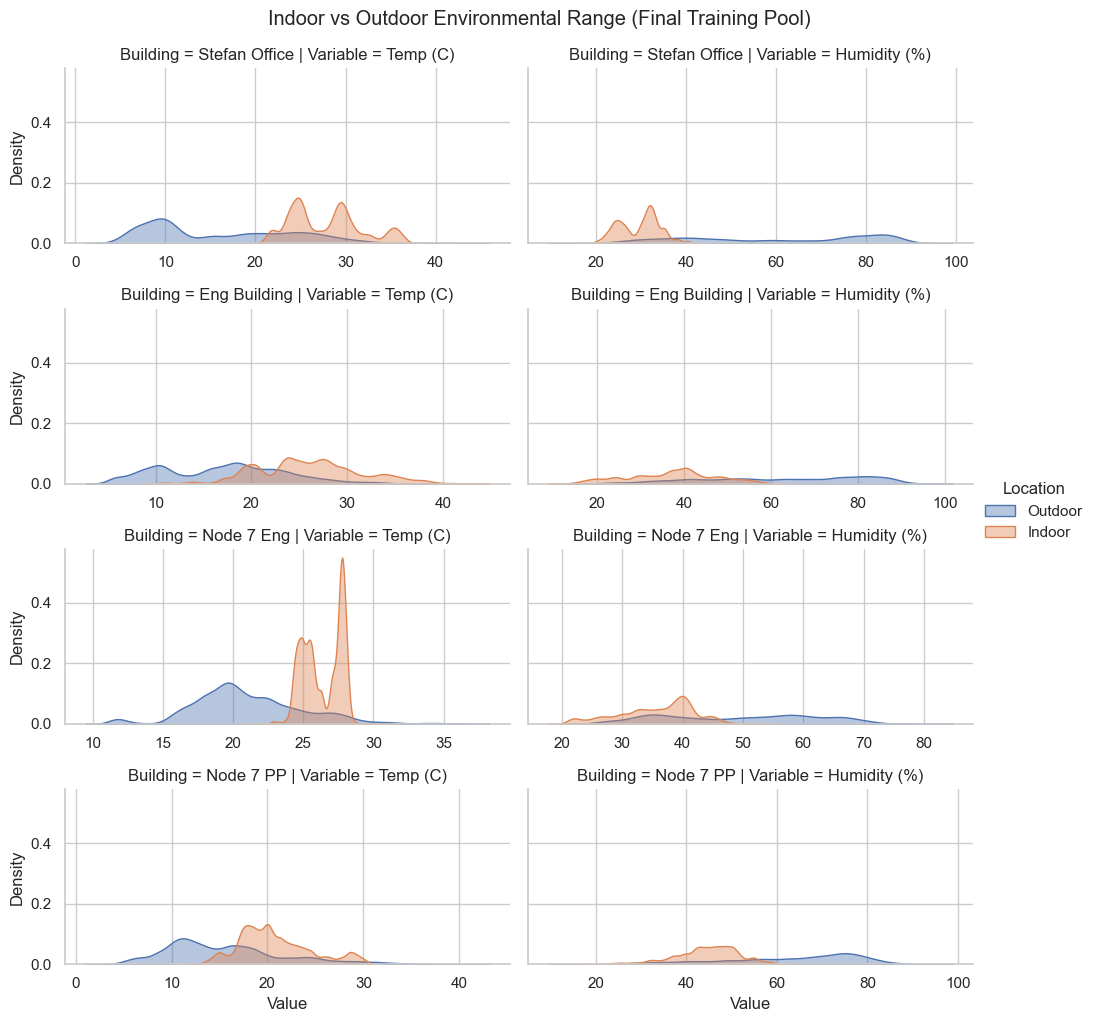

In [10]:
plot_data = []
for b_name, (out_p, in_p) in building_mapping.items():
    pool = training_pools[b_name]
    for var in ['temp', 'humi']:
        for loc, col in [('Outdoor', f'{out_p}_{var}'), ('Indoor', f'{in_p}_{var}')]:
            if col in pool.columns:
                temp_df = pool[[col]].rename(columns={col: 'Value'})
                temp_df['Variable'] = 'Temp (C)' if var == 'temp' else 'Humidity (%)'
                temp_df['Location'] = loc
                temp_df['Building'] = b_name
                plot_data.append(temp_df.dropna())

df_plot = pd.concat(plot_data)
g = sns.FacetGrid(df_plot, col="Variable", row="Building", hue="Location", sharex=False, aspect=2, height=2.5)
g.map(sns.kdeplot, "Value", fill=True, alpha=0.4)
g.add_legend()
g.fig.suptitle("Indoor vs Outdoor Environmental Range (Final Training Pool)", y=1.02)
plt.show()

## 9. PM2.5 Convergence Tracking
A visual check showing the indoor and outdoor sensors tracking each other during selected high-wind periods.

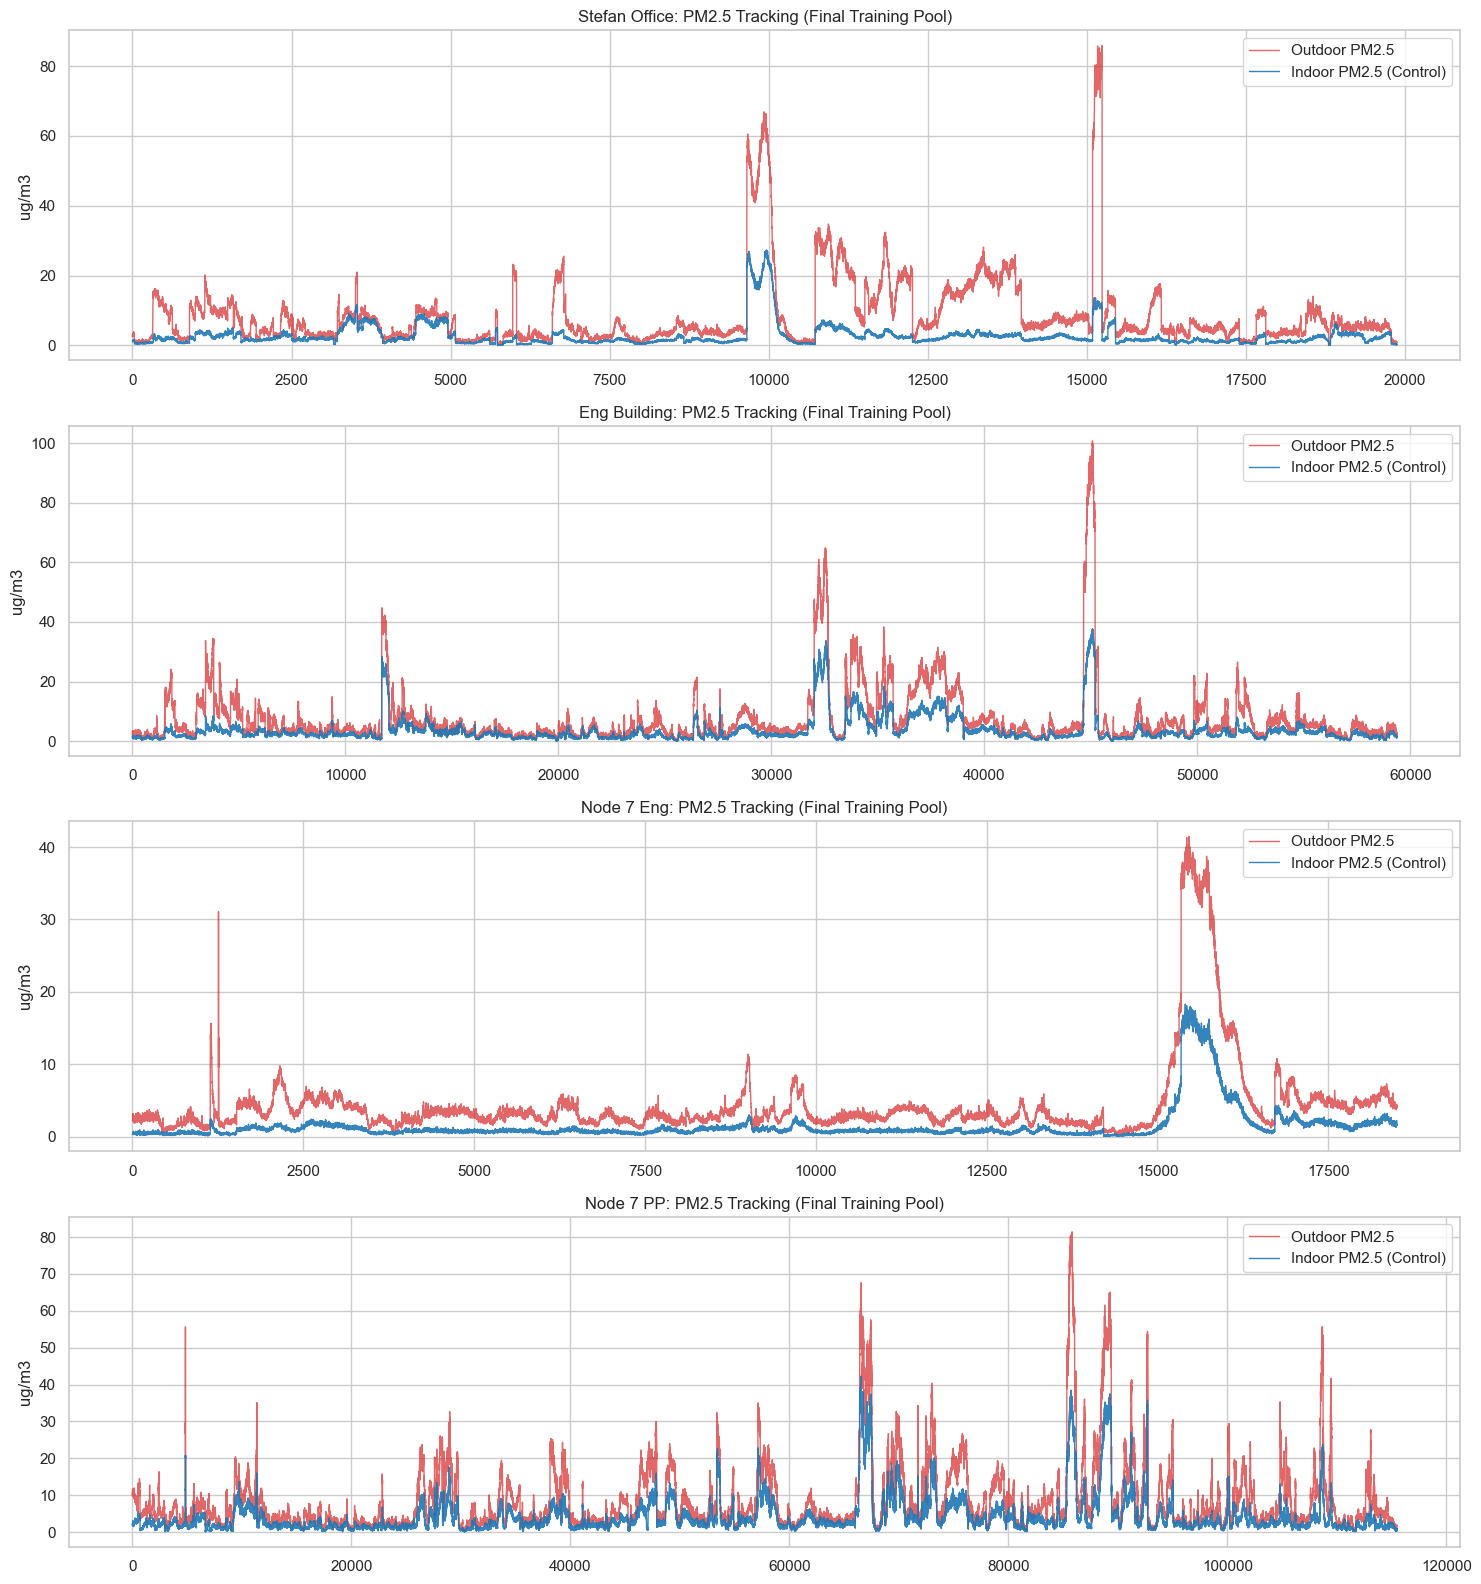

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=False)
for i, b_name in enumerate(building_mapping.keys()):
    pool = training_pools[b_name].sort_values('timestamp_utc').reset_index(drop=True)
    out_p, in_p = building_mapping[b_name]
    axes[i].plot(pool.index, pool[f'{out_p}_pm25'], label='Outdoor PM2.5', alpha=0.7, color='tab:red', linewidth=1)
    axes[i].plot(pool.index, pool[f'{in_p}_pm25'], label='Indoor PM2.5 (Control)', alpha=0.9, color='tab:blue', linewidth=1)
    axes[i].set_title(f"{b_name}: PM2.5 Tracking (Final Training Pool)")
    axes[i].set_ylabel("ug/m3")
    axes[i].legend()
plt.tight_layout()
plt.show()